In [0]:
#!uv pip install --upgrade --no-deps transformers==4.56.2 tokenizers "datasets>=3.4.1,<4.0.0" "huggingface-hub>=0.34.0,<1.0" trl==0.22.2 unsloth unsloth_zoo tqdm multiprocess dill xxhash regex safetensors bitsandbytes accelerate peft

In [0]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [0]:
!nvidia-smi

Thu Nov 20 13:24:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:53:00.0 Off |                    0 |
| N/A   24C    P0             66W /  700W |       4MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [0]:
%restart_python

In [0]:
from datasets import load_dataset, Dataset
from unsloth.chat_templates import get_chat_template

from unsloth import FastLanguageModel
import torch

from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback
from unsloth.chat_templates import train_on_responses_only
from transformers import TextStreamer

import pandas as pd
import matplotlib.pyplot as plt
import json

/local_disk0/.ephemeral_nfs/envs/pythonEnv-fe0d12ef-5aee-4891-852d-cd78eee94f9c/lib/python3.12/site-packages/torch/__init__.py:2099: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  _C._initExtension(_manager_path())


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


### Load model and tokenizer

In [0]:
fourbit_models = [
    "unsloth/Qwen3-4B-Instruct-2507-unsloth-bnb-4bit", # Qwen 14B 2x faster
    "unsloth/Qwen3-4B-Thinking-2507-unsloth-bnb-4bit",
    "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    "unsloth/Qwen3-14B-unsloth-bnb-4bit",
    "unsloth/Qwen3-32B-unsloth-bnb-4bit",

    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/Phi-4",
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/orpheus-3b-0.1-ft-unsloth-bnb-4bit" # [NEW] We support TTS models!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-4B-Thinking-2507",
    max_seq_length = 4096, #2048, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    load_in_8bit = False, # [NEW!] A bit more accurate, uses 2x memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
)

==((====))==  Unsloth 2025.11.3: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 8. Max memory: 79.096 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

<img src=https://miro.medium.com/v2/resize:fit:1400/format:webp/1*_WzTdYz-vXb7kip3DToOEA.png height = 350>

In [ ]:
P = 4
Q = 4

M = (P * 4) / (32 / Q) * 1.2
print(f'Memory needed: {M:.2f} GB')

# Or same calc: Param * 4 / (32 / BitQuant)
M_ = 4 * 4 / (32 / 4) * 1.2
print(f'Memory needed: {M_:.2f} GB')

Memory needed: 2.40 GB
Memory needed: 2.40 GB


In [0]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 64,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2025.11.3 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


<img src=https://dagshub.com/blog/content/images/2024/04/lora.jpeg height = 350>

Blogpost from Thinking Labs about LORA: https://thinkingmachines.ai/blog/lora/

In [0]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "qwen3-thinking",
)

Test inference

In [0]:
messages = [
    {"role" : "user", "content" : "What is the capital of Hungary?"}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
    enable_thinking = False, # Disable thinking
)

_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 450, # Increase for longer outputs!
    temperature = 0.7, top_p = 0.8, top_k = 20, # For non thinking
    streamer = TextStreamer(tokenizer, skip_prompt = False),
)

<|im_start|>user
What is the capital of Hungary?<|im_end|>
<|im_start|>assistant
<think>
Okay, the user is asking about the capital of Hungary. Hmm, this seems like a straightforward geography question. Let me quickly verify the answer to be sure. 

I recall that Budapest is the capital of Hungary. But wait, just to be thorough—I should double-check because sometimes people confuse it with other cities. 

*Quick mental scan of Hungarian geography* Yep, Budapest is definitely the capital. It's a dual city with Buda and Pest, and it's been the capital since 1849. 

The user might be a student working on homework, a traveler planning a trip, or just someone curious. Since they didn't provide context, I'll keep it simple and factual. 

I wonder if they need more details? Like why Budapest is the capital or interesting facts about it. But since they only asked for the capital name, I shouldn't overcomplicate it. 

*Double-checking sources in my mind* No, I'm confident—Budapest is correct. S

### Load dataset

In [0]:
with open('training_data_examples_all.jsonl', 'r') as f:
    training_data = [json.loads(line) for line in f]

print(f"Loaded {len(training_data)} training examples")

Loaded 5154 training examples


In [0]:
n_examples = len(training_data)

TRAIN_SIZE = 0.7
EVAL_SIZE = 0.15
TEST_SIZE = 1-TRAIN_SIZE-EVAL_SIZE

n_train = int(n_examples * TRAIN_SIZE)
n_eval = int(n_examples * EVAL_SIZE)
n_test = n_examples - n_train - n_eval

# Assign IDs to each split
train_ids = list(range(0, n_train))
eval_ids = list(range(n_train, n_train + n_eval))
test_ids = list(range(n_train + n_eval, n_examples))

train_data = [training_data[i] for i in train_ids]
eval_data = [training_data[i] for i in eval_ids]
test_data = [training_data[i] for i in test_ids]

print(f"Total examples: {n_examples}")
print(f"Training examples: {len(train_data)}")
print(f"Eval examples: {len(eval_data)}")
print(f"Test examples: {len(test_data)}")

Total examples: 5154
Training examples: 3607
Eval examples: 773
Test examples: 774


In [0]:
def preprocess_data(data):
    df = pd.DataFrame.from_dict(data)
    df["user_message"] = "Here is the research report gathered from internal / external sources. Proceed to give your verdict on the investment opportunity. \n\n" + df["report"]
    df["assistant_output"] = "<think>\n" + df["reasoning"] + "\n</think>" + df["verdict"].astype(str)
    df.drop(["report", "reasoning", "verdict"], axis=1, inplace=True)
    return df

In [0]:
train_df = preprocess_data(train_data)
eval_df = preprocess_data(eval_data)
test_df = preprocess_data(test_data)

### Format to Dataset structure

In [0]:
train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)
test_dataset = Dataset.from_pandas(test_df)

In [0]:
def generate_conversation(examples):
    problems  = examples["user_message"]
    solutions = examples["assistant_output"]
    conversations = []
    for problem, solution in zip(problems, solutions):
        conversations.append([
            {"role" : "user",      "content" : problem},
            {"role" : "assistant", "content" : solution},
        ])
    return { "conversations": conversations, }
  

def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
   return { "text" : texts, }

In [0]:
train_dataset = train_dataset.map(generate_conversation, batched = True)
train_dataset = train_dataset.map(formatting_prompts_func, batched = True)

eval_dataset = eval_dataset.map(generate_conversation, batched = True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched = True)

test_dataset = test_dataset.map(generate_conversation, batched = True)
test_dataset = test_dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/3607 [00:00<?, ? examples/s]

Map:   0%|          | 0/3607 [00:00<?, ? examples/s]

Map:   0%|          | 0/773 [00:00<?, ? examples/s]

Map:   0%|          | 0/773 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

Map:   0%|          | 0/774 [00:00<?, ? examples/s]

In [0]:
train_dataset[100]['text']

'<|im_start|>user\nHere is the research report gathered from internal / external sources. Proceed to give your verdict on the investment opportunity. \n\nDate: April 10, 2026\n\nI. Company Overview and Business Model\n\n– AquaHarvest Inc. is a U.S.-based agricultural technology startup specializing in advanced vertical farming solutions tailored for leafy greens and herbs using proprietary aeroponic systems and AI-driven environmental controls.\n– Founded in 2018, headquartered in San Jose, California.\n– Business Model:\n  • Sells modular vertical farming units to commercial growers, grocery chains, and urban agriculture startups.\n  • Provides ongoing SaaS subscription for AI-environmental monitoring and optimization.\n  • Offers consulting and installation services for farm setup and customization.\n\n– Revenue breakdown FY25:\n  • Hardware sales: 65%\n  • SaaS subscriptions: 25%\n  • Services: 10%\n\n– Scale:\n  • FY25 revenue: $85 million, up from $42 million in FY24 (102% YoY gro

### Set up trainer

In [ ]:
import mlflow
from datetime import datetime

mlflow.set_experiment('/Users/kristof.rabay/qwen3-4b-winterfest')

In [0]:
run_name = f"qwen3-4b-sft-winterfest-{datetime.now().strftime('%Y-%m-%d-%H-%M-%s')}"
print(run_name)

qwen3-4b-sft-winterfest-2025-11-20-13-26-1763645194


In [0]:
steps_per_epoch = len(train_dataset) // (4 * 8 * 1)
print(steps_per_epoch)

112


In [0]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset=eval_dataset,
    #n_gpus = 8,
    args = SFTConfig(
        per_device_train_batch_size = 4,#1,
        gradient_accumulation_steps = 8,

        # num_train_epochs = 1, # Set this for 1 full training run.
        # num_train_epochs = 3,
        max_steps = 300,#30,
        #max_steps = -1,

        learning_rate = 3e-5, #5e-5, #2e-4, #2e-6,#2e-4,
        lr_scheduler_type = "cosine", #cosine?, linear?
        #warmup_steps = 5,
        warmup_ratio = 0.05,

        eval_steps = 25,                   # Add evaluation
        eval_strategy = "steps",           # Evaluate during training
        save_steps = 150,
        save_total_limit = 3,

        optim = "adamw_8bit",
        weight_decay = 0.01,

        metric_for_best_model = 'eval_loss', # for early stopping
        load_best_model_at_end=True, # for early stopping
        logging_steps = 5,

        seed = 3407,
        output_dir = "outputs",
        report_to = 'mlflow',#"none", # Use TrackIO/WandB etc
        run_name = run_name,
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/3607 [00:00<?, ? examples/s]

I0000 00:00:1763645349.650456   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1763645349.732021   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1763645349.799725   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1763645349.867290   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1763645349.930756   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers


Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/773 [00:00<?, ? examples/s]

In [0]:
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

Map (num_proc=64):   0%|          | 0/3607 [00:00<?, ? examples/s]

Map (num_proc=64):   0%|          | 0/773 [00:00<?, ? examples/s]

I0000 00:00:1763645410.435463   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1763645410.533477   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1763645410.636349   10221 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers


In [0]:
#tokenizer.decode(trainer.train_dataset[100]["input_ids"])

In [0]:
#tokenizer.decode([tokenizer.pad_token_id if x == -100 else x for x in trainer.train_dataset[100]["labels"]]).replace(tokenizer.pad_token, " ")

In [0]:
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience = 5,  # Increase from 3 (5 eval cycles = 250 steps)
    early_stopping_threshold = 0.001,  # Require 0.1% improvement
)
trainer.add_callback(early_stopping_callback)

### Kick off training

In [0]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA H100 80GB HBM3. Max memory = 79.096 GB.
3.955 GB of memory reserved.


In [0]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,607 | Num Epochs = 3 | Total steps = 300
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)
2025/11/20 13:30:42 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,1.609900,1.570013
50,1.352700,1.340163
75,1.289700,1.278234
100,1.262100,1.244637
125,1.213300,1.223315
150,1.201600,1.209014
175,1.202300,1.199075
200,1.196300,1.192175
225,1.170300,1.188123
250,1.197000,1.186052


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
2025/11/20 14:22:57 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2025/11/20 14:22:57 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [0]:
# Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

3134.1563 seconds used for training.
52.24 minutes used for training.
Peak reserved memory = 25.414 GB.
Peak reserved memory for training = 21.459 GB.
Peak reserved memory % of max memory = 32.131 %.
Peak reserved memory for training % of max memory = 27.13 %.


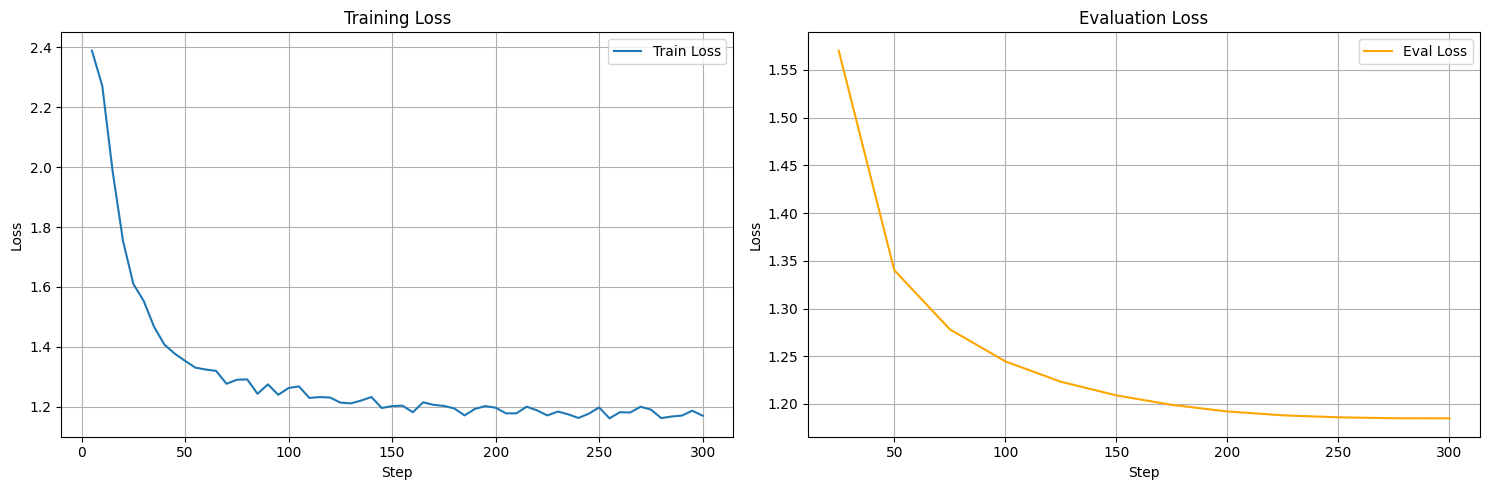

In [0]:
# Load training history from MLflow
history = trainer.state.log_history

# Create DataFrame
df_history = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training loss
train_df = df_history[df_history['loss'].notna()]
ax1.plot(train_df['step'], train_df['loss'], label='Train Loss')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

# Eval loss
eval_df = df_history[df_history['eval_loss'].notna()]
ax2.plot(eval_df['step'], eval_df['eval_loss'], label='Eval Loss', color='orange')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Evaluation Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [0]:
#df_history.to_csv('training_history.csv')

In [0]:
# Check for overfitting
final_train_loss = train_df['loss'].iloc[-5:].mean()
final_eval_loss = eval_df['eval_loss'].iloc[-3:].mean()
gap = final_eval_loss - final_train_loss

print(f"Final Train Loss (avg last 5): {final_train_loss:.4f}")
print(f"Final Eval Loss (avg last 3): {final_eval_loss:.4f}")
print(f"Gap: {gap:.4f}")

if gap > 0.1:
    print("⚠️ Possible overfitting - consider: lower LoRA rank, higher weight decay, or dropout")
elif gap < 0.05:
    print("✅ Good generalization - model is learning well")

Final Train Loss (avg last 5): 1.1708
Final Eval Loss (avg last 3): 1.1854
Gap: 0.0146
✅ Good generalization - model is learning well


### Inference

First, test if it's still a 'general' model

In [0]:
messages = [
    {"role" : "user", "content" : "What is the capital of Hungary?"}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
    enable_thinking = False, # Disable thinking
)

_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 1000, # Increase for longer outputs!
    temperature = 0.7, top_p = 0.8, top_k = 20, # For non thinking
    streamer = TextStreamer(tokenizer, skip_prompt = False),
)

<|im_start|>user
What is the capital of Hungary?<|im_end|>
<|im_start|>assistant
<think>
Okay, the user is asking about the capital of Hungary. That seems straightforward, but let me double-check to be absolutely sure. I recall that Budapest is the capital city of Hungary, located on both sides of the Danube River. 

Hmm, why might someone ask this? They could be studying geography, preparing for a trivia quiz, or planning a trip to Hungary. Maybe they're confused because Hungary has a long history and some cities might be mistaken for capitals. 

I should confirm there's no recent change—no, Budapest has been the capital since 1849 and was historically the seat of the Hungarian monarchy. Also, the city's name comes from the Hungarian "Budapest" meaning "city of the river" or "river bend." 

The user might appreciate a bit more context—like Budapest being the largest city in Hungary and a major cultural hub. But since the question is direct, I'll keep the answer concise but add a fun f

Now test if it's been adapted for Investment Opportunity Eval

In [0]:
research_material = "Stock is a good stock, competition is a bad competition. Demand for company's products is OK."

messages = [
    {"role" : "user", "content" : f"""Here is the research report gathered from internal / external sources. Proceed to give your verdict on the investment opportunity.
     
    {research_material}
    """}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
    enable_thinking = False, # Disable thinking
)

_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 2048, # Increase for longer outputs!
    temperature = 0.2, top_p = 0.8, top_k = 20, # For non thinking
    streamer = TextStreamer(tokenizer, skip_prompt = False),
)

<|im_start|>user
Here is the research report gathered from internal / external sources. Proceed to give your verdict on the investment opportunity.
     
    Company is a good company, competition is a bad competition. Demand for company's products is OK.
    <|im_end|>
<|im_start|>assistant
<think>
Okay, looking at this company, it seems to be in a decent position with some positive aspects. The phrase "good company" suggests solid fundamentals, maybe strong management or a decent market position. The competition being a "bad competition" is interesting—it implies that the company faces competitors who are weaker or less capable, which is a positive sign for the company's market position and potential for growth.

The demand for the company's products is described as "OK," which is a bit neutral. It means there's some demand but not strong or growing rapidly. This could be a concern if the market is stagnant or if the company struggles to differentiate its products.

Let me analyze th

```markdown

<|im_start|>user
Here is the research report gathered from internal / external sources. Proceed to give your verdict on the investment opportunity.
     
Stock is a good stock, competition is a bad competition. Demand for company's products is OK.
<|im_end|>
<|im_start|>assistant

<think>
Okay, looking at this company, it seems to be in a decent position with some positive aspects. The phrase "good stock" suggests solid fundamentals, maybe strong management or a decent market position. The competition being a "bad competition" is interesting—it implies that the company faces competitors who are weaker or less capable, which is a positive sign for the company's market position and potential for growth.

The demand for the company's products is described as "OK," which is a bit neutral. It means there's some demand but not strong or growing rapidly. This could be a concern if the market is stagnant or if the company struggles to differentiate its products.

Let me analyze the competitive landscape further. If the competition is weak or less capable, the company might have pricing power or market share advantages. However, if the competition is just "bad," it might also mean that the market is not very attractive or that the company is vulnerable to new entrants or disruptive technologies.

On the demand side, "OK" demand suggests that the company is not a market leader or innovator. It might be a niche player or serving a limited customer base. This could limit growth opportunities unless the company can improve its product offerings or expand into new markets.

Considering the overall picture, the company has some positives but also some red flags. The weak competition is a plus, but the "OK" demand and the lack of clear growth drivers raise concerns. Without more details on the company's financials, market share, product innovation, or competitive advantages, it's hard to be confident.

Therefore, I would say the investment signal is questionable. There are some positives but also significant uncertainties and risks that warrant further due diligence before committing capital.
</think>

{
    'proceed_signal': 'questionable', 
    
    'evidence_pro': '1. The stock is described as a "good stock," suggesting solid fundamentals and management.\n2. The competition is characterized as "bad," indicating potential advantages in market positioning or pricing power.\n3. The company has some demand for its products, which is a baseline for viability.',
    
    'evidence_contra': '1. Demand for products is only "OK," indicating limited growth or market traction.\n2. The competitive landscape, while described as weak, may not be strong enough to sustain long-term market leadership.\n3. Lack of clear information on financial health, innovation pipeline, or customer retention raises concerns about sustainability.\n4. The market may be mature or stagnant, limiting growth opportunities.', 
    
    'key_information_requested': '1. Detailed financial statements and profitability trends.\n2. Competitive analysis including customer concentration and switching costs.\n3. Product innovation roadmap and R&D spend.\n4. Market size and growth projections.\n5. Management team's track record and strategic plans.'

}
<|im_end|>

```

### Save snapshot

In [0]:
model.save_pretrained("verdict_model")  # Local saving
tokenizer.save_pretrained("verdict_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

('verdict_model/tokenizer_config.json',
 'verdict_model/special_tokens_map.json',
 'verdict_model/chat_template.jinja',
 'verdict_model/vocab.json',
 'verdict_model/merges.txt',
 'verdict_model/added_tokens.json',
 'verdict_model/tokenizer.json')

In [0]:
# Set False to True to read local model:
if False:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = "verdict_model", # YOUR MODEL YOU USED FOR TRAINING
        max_seq_length = 2048,
        load_in_4bit = True,
    )